# UCB CE170A Quiz 3: Model bridge experiment data analysis and structural analysis using a Python code
v3 - Fall 2022: Prof. Kenichi Soga, Jaewon Saw, Yaobin Yang

v2 - Fall 2021: Prof. Kenichi Soga, Renjie Wu, Yaobin Yang

# Install required packages

In [1]:
!pip install trusspy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 kB 2.2 MB/s eta 0:00:00


# Background

<center>
<img src="https://github.com/UCB-CE170a/Fall2020/raw/master/homeworks/hw1/images/figure0.png" alt="A bridge." width="400" />
    
    An example bridge
</center>


A photo and schematic diagram of the model bridge is shown in Fig. 1. The model consists of two identical 2D frames placed in parallel and connected by diagonal and horizonal braces (Pink lines). A vertical load will be applied at the top two nodes using a load spreader frame (light Blue). In the experiment, the model bridge will be placed between two rigid supports as shown in Fig. 2.




<center>
<img src="https://github.com/UCB-CE170a/Fall2020/raw/master/homeworks/hw1/images/figure1.png" alt="schematic diagram." width="600" />
    
    Figure 1. A photo and schematic diagram of the model bridge
</center>

<center>
<img src="https://github.com/UCB-CE170a/Fall2021/raw/master/Homeworks/HW2/images/figure2.png" alt="A bridge." width="500" />
    
    Figure 2. Loading on the model bridge
</center>

The bridge is made of aluminum  angle bars and sheets as shown in Fig. 3. The angle bar has a **cross-sectional dimension of ½ inch x ½ inch x 3/80 inch (thickness)(cross-sectional area = 1.51 x 10$^{-4}$ m$^{2}$)**. Two angle bars are used for the top four frame members (Yellow lines in Fig. 1 or L2 & L3 in Fig. 2), whereas one angle bar is used for the other members (Red, Blue and Pink lines in Fig. 1 or L4 & L5 in Fig. 2). The Young’s modulus and yield strength of the angle bar are **69 GPa and 110 MPa,** respectively. The members are connected by rivets.

The design details of the model bridge are given in Fig. 4.


<center>
<img src="https://github.com/UCB-CE170a/Fall2020/raw/master/homeworks/hw1/images/figure3.png" alt="A bridge." width="400" />
    
    Figure 3. Aluminum angle bars and sheets used by the bridge
</center>


<center>
<img src="https://github.com/UCB-CE170a/Fall2021/raw/master/Homeworks/HW2/images/figure4.png" alt="A bridge." width="600" />
    
    Figure 4. Design details of the model
</center>



# Question 1:
A working load of 7000 N is applied to the model structure. Using a simplified 2D model shown in Fig. 5, perform a hand calculation of the bar forces and strains under the given load for load carrying sections, L1, L2 and L3. What is the role of bracing sections L4, L5?  Estimate the displacement at the top nodes.

Note: for the 2D model, the actual force of the top node is half of the total force

Hint: use the virtual work method for displacement calculation.
See https://learnaboutstructures.com/Virtual-Work-for-Trusses for an example.


<center>
<img src="https://github.com/UCB-CE170a/Fall2021/raw/master/Homeworks/HW2/images/figure5b.png" alt="A bridge." width="500" />
    
    Figure 5. A simplified 2D model of the model bridge (dimension in meters)
</center>

# Question 2:
Following code blocks below to use [Trusspy](https://trusspy.readthedocs.io/en/latest/) to model the 3D model bridge. Run all the cells and **fill the TODO** parts if necessary.


In [2]:
"""
Step 0: Import libraries
"""
import trusspy as tp
import copy
import matplotlib.pyplot as plt
import numpy as np

First, lets declare constant variables and initialize the Trusspy model. Fill the empty constants using the information provided by the question description.

In [5]:
"""
Step 1: Assign Constant and initialze the model
"""
ELEMENT_TYPE   = 1    # truss
MATERIAL_TYPE  = 2    # elasto-plastic
HARDENING_MODULUS = 0.01 # hardening_modulus[Pa] a very small number for elastic-perfectly plastic
INCREMENT = 40

# TODO: Assign proper values below
A =  0.000151 # the area of the angle bar section [m^2]
YONGS_MODULUS =  69000000000 # Young's modulus [Pa]
YIELD_STRENGH =  110000000 # yield strength [Pa]


M_perfect = tp.Model(log = 0)# Trusspy model initialization

# model settings
M_perfect.Settings.dlpf = 0.1
M_perfect.Settings.du = 0.002
M_perfect.Settings.incs = INCREMENT
M_perfect.Settings.stepcontrol = True


Second, lets add nodes into the initialized null model. Model configuration is shown be the figure below:

<center>
<img src="https://github.com/UCB-CE170a/Fall2020/raw/master/homeworks/hw1/images/model_configuration.png" alt="A bridge." width="600" />
    
    Figure 5. Trusspy model configuration
</center>


In [6]:
"""
Step 2: Add truss elements to the model
"""
with M_perfect.Nodes as MN:# nodes defination unit [m]
    MN.add_node( 1, coord=(0,0,0))
    MN.add_node( 2, coord=(1,0,0))
    MN.add_node( 3, coord=(2,0,0))
    MN.add_node( 4, coord=(0.5,0,0.5))
    MN.add_node( 5, coord=(1.5,0,0.5))
    MN.add_node( 6, coord=(1,0,1))
    MN.add_node( 7, coord=(0,0.2876,0))
    MN.add_node( 8, coord=(1,0.2876,0))
    MN.add_node( 9, coord=(2,0.2876,0))
    MN.add_node( 10, coord=(0.5,0.2876,0.5))
    MN.add_node( 11, coord=(1.5,0.2876,0.5))
    MN.add_node( 12, coord=(1,0.2876,1))

Then we link all these nodes together to construct the configuration shown by figure 5.

In [7]:
"""
Step 3: Add truss elements to the model
"""
with M_perfect.Elements as ME:
    ME.add_element( 1, conn=(1,2), gprop=[A] )
    ME.add_element( 2 ,conn=(2,3), gprop=[A] )
    ME.add_element( 3, conn=(1,4), gprop=[A*2] )
    ME.add_element( 4, conn=(2,4), gprop=[A] )
    ME.add_element( 5, conn=(2,5), gprop=[A] )
    ME.add_element( 6, conn=(3,5), gprop=[A*2] )
    ME.add_element( 7, conn=(4,6), gprop=[A*2] )
    ME.add_element( 8, conn=(5,6), gprop=[A*2] )
    ME.add_element( 9, conn=(7,8), gprop=[A] )
    ME.add_element( 10 ,conn=(8,9), gprop=[A] )
    ME.add_element( 11, conn=(7,10), gprop=[A*2] )
    ME.add_element( 12, conn=(8,10), gprop=[A] )
    ME.add_element( 13, conn=(8,11), gprop=[A] )
    ME.add_element( 14, conn=(9,11), gprop=[A*2] )
    ME.add_element( 15, conn=(10,12), gprop=[A*2] )
    ME.add_element( 16, conn=(11,12), gprop=[A*2] )
    ME.add_element( 17, conn=(1,10), gprop=[A] )
    ME.add_element( 18, conn=(4,12), gprop=[A] )
    ME.add_element( 19, conn=(6,11), gprop=[A] )
    ME.add_element( 20, conn=(5,9), gprop=[A] )
    ME.add_element( 21, conn=(6,12), gprop=[A] )
    ME.add_element( 22, conn=(6,12), gprop=[A] )
    ME.add_element( 23, conn=(1,7), gprop=[A] )
    ME.add_element( 24, conn=(3,9), gprop=[A] )
    ME.add_element( 25, conn=(4,10), gprop=[A] )
    ME.add_element( 26, conn=(5,11), gprop=[A] )
    ME.assign_etype(    'all',   ELEMENT_TYPE   )
    ME.assign_mtype(    'all',  MATERIAL_TYPE   )
    ME.assign_material( 'all', [YONGS_MODULUS,HARDENING_MODULUS,YIELD_STRENGH] )

Lets assign external forces and boundary conditions to the model:

In [8]:
"""
Step 4: Set boundary conditions and external forces
"""
# TODO: WHAT IS THE LOAD?
load = 7000 #Assuming this value is meant to be in Newtons
load1= -0.5*load # front force
load2= -0.5*load # back force

with M_perfect.Boundaries as MB: # boundary-displacement
    MB.add_bound_U( 1, (0,0,0) )
    MB.add_bound_U( 3, (1,1,0) )
    MB.add_bound_U( 7, (0,1,0) )
    MB.add_bound_U( 9, (1,1,0) )
    MB.add_bound_U( 2, (1,0,1) ) # this is a difference between our model and realistic word, since there is no joint in the real world for node 2 and 8
    MB.add_bound_U( 8, (1,0,1) ) # since there is no joint in the real world for node 2 and 8

with M_perfect.ExtForces as MF: # boundary-force
    MF.add_force( 6, ( 0, 0, load1) )
    MF.add_force( 12, ( 0, 0, load2) )


Finally, lets build and run the model:

In [9]:
"""
Step 5: Build and run the model
"""
M_perfect.build()
M_perfect.run()
print ("Simulation finished")


* increase NR-step size by factor:       1.21
* increase NR-step size by factor:       1.36
* increase NR-step size by factor:       1.36
* increase NR-step size by factor:       1.29
* reduce NR-step size by factor: (inactive) due to recycle.
* reduce NR-step size by factor:      0.125

* recycling increment
* increase NR-step (inactive). incs since last reduction: 1/3
* increase NR-step (inactive). incs since last reduction: 2/3
* increase NR-step (inactive). incs since last reduction: 3/3
* increase NR-step size by factor:       1.36
* increase NR-step size by factor:       1.36
* increase NR-step size by factor:       1.36
* increase NR-step size by factor:       1.36
* increase NR-step size by factor:       1.29
* increase NR-step size by factor:       1.29
* increase NR-step size by factor:       1.29
* increase NR-step size by factor:       1.29
* increase NR-step size by factor:       1.29
* increase NR-step size by factor:       1.36
* increase NR-step size by factor:       1.

If your model is built successfully, you will see "Simulation finished" on the bottom of the above cell. Run cell below to plot the model in 3D.

<Figure size 640x480 with 0 Axes>

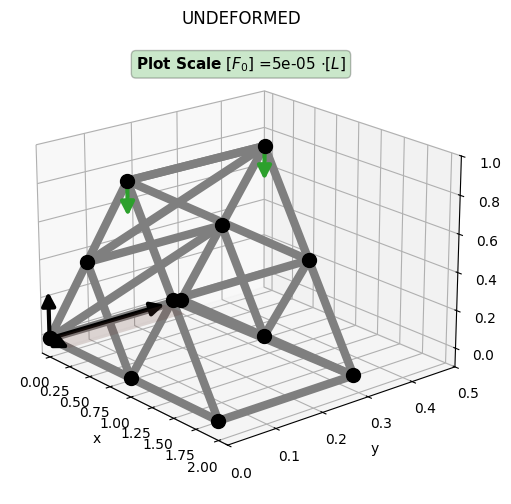

In [10]:
# View the initial model in 3D
fig, ax = M_perfect.plot_model(
                      view='3d', #'xy', 'yz', 'xz'
                      contour='force',
                      lim_scale=(-0.1,2.1,0,0.5,-0.1,1), #3d
                      force_scale=0.00005, #2
                      inc=0)

Trusspy allows us to view the deformation in 3D:

<Figure size 640x480 with 0 Axes>

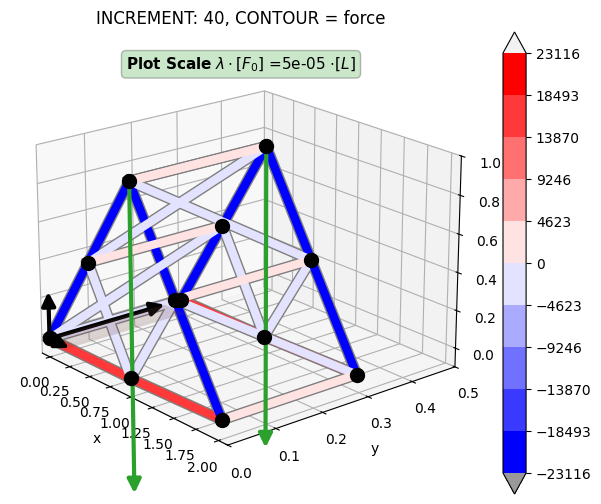

In [11]:
fig, ax = M_perfect.plot_model(
                        view='3d', #'xy', 'yz', 'xz'
                        contour='force',
                        lim_scale=(-0.1,2.1,0,0.5,-0.1,1), #3d
                        force_scale=0.00005, #2
                        inc=-1)

And in 2d view:

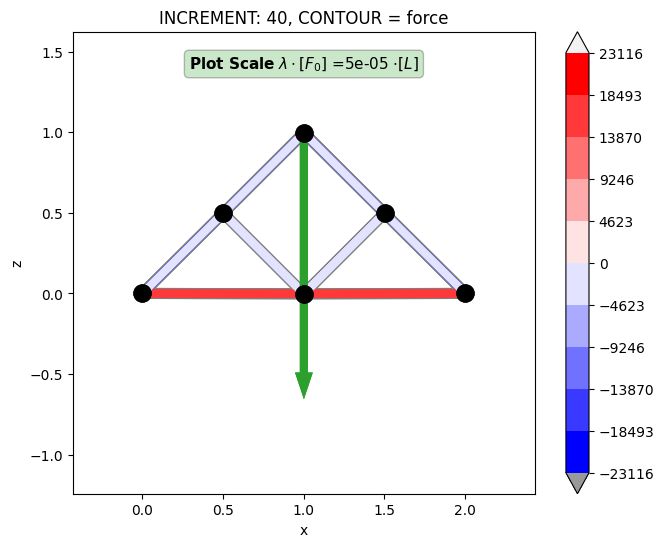

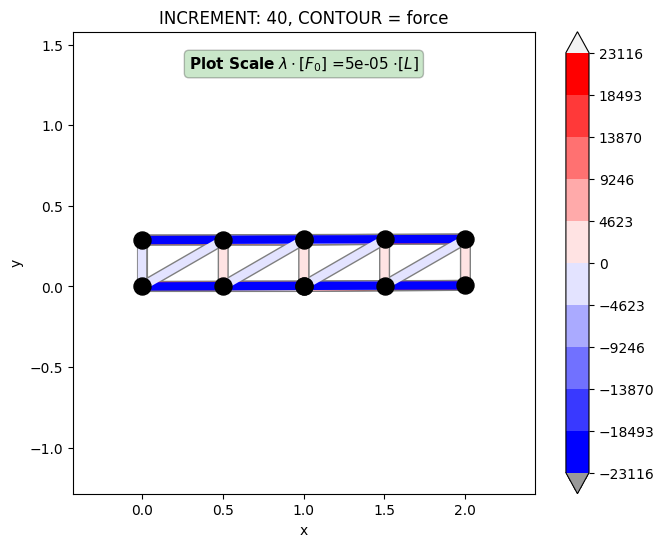

In [12]:
# "Deformed model in xz plane view"
fig, ax = M_perfect.plot_model(
                        view='xz',
                        contour='force',
                        lim_scale=1.3,
                        force_scale=0.00005,
                        inc=-1)

# Deformed model in xy plane'
fig, ax = M_perfect.plot_model(
                        view='xy',
                        contour='force',
                        lim_scale=1.3,
                        force_scale=0.00005,
                        inc=-1)

## Plot elements responses during loading.


We are going to create some help functions to assess elements responses of the model during the loading process.

First, lets create a function to get the internal forces of a truss element with respect to the load proportionality factor (LPF).

Note: Since we are really kind, all the functions are already created for you. Your job is to read the function and experiment the usages in this quiz.

In [13]:
def get_internal_forces(M,elem):
  """Get internal force of a element
    Args:
      M: trusspy model
      elem: the element index of interest

    Returns:
      lpfs is a list of loading proportionality factor for this elem
      forces is a list of internal force for this elem regarding to lpfs
  """
  Res=M.Results.R
  lpfs,forces = [],[]
  for r in Res:
      force =r.element_force[elem-1]
      lpfs.append(r.lpf)
      forces.append(force[0])
  return lpfs,forces


Using the extracted force to create a function that computes stresses of an element regarding to LPFs:

In [14]:
def get_stresses(M,elem):
  """Get stress of a element
    Args:
      M: trusspy model
      elem: the element index of interest

    Returns:
      lpfs is a list of loading proportionality factor for this elem
      stresses is a list of stress for this elem regarding to lpfs
  """
  area = M.Elements.geometric_properties[elem-1][0]
  lpfs,forces = get_internal_forces(M,elem)
  stresses = list(map(lambda f:f/area, forces))
  return lpfs,stresses

Now, lets compute strains.

In [15]:
def get_strains(M,elem):
  """Get strain of a element
    Args:
      M: trusspy model
      elem: the element index of interest

    Returns:
      lpfs is a list of loading proportionality factor for this elem
      strains is a list of strain for this elem regarding to lpfs
  """
  E=M.Elements.material_properties[elem-1][0]
  lpfs,stresses = get_stresses(M,elem)
  strains=list(map(lambda stress:stress/E, stresses))
  return lpfs,strains

And rotation degrees of a element.

In [16]:
def get_rotation_degrees(M,elem):
  """Get rotation degrees of a element
    Args:
      M: trusspy model
      elem: the element index of interest

    Returns:
      lpfs is a list of loading proportionality factor for this elem
      degrees is a list of rotation degree for this elem regarding to lpfs
  """
  con=M.Elements.conns[elem-1] # element names are 1-based whereas list indexes are 0-based
  node1,node2 =con[0], con[1]
  coord1,coord2=M.Nodes.coords[node1-1], M.Nodes.coords[node2-1] # node names are 1-based whereas list indexes are 0-based
  r_before = coord2-coord1 # initial vector representation of the truss element

  Res=M.Results.R
  lpfs,degrees = [],[]
  for Re in Res:
      n1_displacement = Re.U[node1-1]
      n2_displacement = Re.U[node2-1]

      # Get the coordinates of the two nodes after stressing.
      coord1_after = coord1+n1_displacement
      coord2_after = coord2+n2_displacement

      # Use all the information to get the rotation degree: theta
      # Hint: How do you get the angle of two vector? np.dot might be helpful
      r_after=coord2_after-coord1_after
      cosangle = r_before.dot(r_after)/(np.linalg.norm(r_before) * np.linalg.norm(r_after))
      theta=np.arccos(cosangle)
      lpfs.append(Re.lpf)
      degrees.append(theta)
  return lpfs,degrees


Use the created functions to plot the following with increasing load (LPFs).

### Q2 a): Strains and rotations in element L2







What is the internal force and strain of L2 when LPF is around 1? (use the closest LPF and the corresponding values). Compare and discuss values from simulation to your results in question 1.

In [71]:
# TO DO: code to get the values (call the right functions and select values correspond to LPF = 1)

M = M_perfect
elem = 7

# 1) Internal force at LPF ~ 1
lpfs, forces = get_internal_forces(M_perfect, elem)
i = min(range(len(lpfs)), key=lambda k: abs(float(lpfs[k]) - 1.0))  # nearest to LPF=1
lpf_star = float(lpfs[i])
F_L2_at1 = float(forces[i])
print(f"L2 force @ LPF≈{lpf_star:.3f} = {F_L2_at1:.3f} N")

# 2) Strain at LPF ~ 1
lpfs_s, strains = get_strains(M_perfect, elem)
j = min(range(len(lpfs_s)), key=lambda k: abs(float(lpfs_s[k]) - 1.0))
lpf_star_s = float(lpfs_s[j])
eps_L2_at1 = float(strains[j])
print(f"L2 strain @ LPF≈{lpf_star_s:.3f} = {eps_L2_at1:.6e}")

L2 force @ LPF≈0.994 = -2461.495 N
L2 strain @ LPF≈0.994 = -1.181253e-04


<font color=”blue”> Your Answer </font> : In this simulation run I see that for L2 the force is calculated as 2,461.495 N in compression, which is very close to the 2,474.87 N in compression calculated by hand. And then with this simulation I received a strain of -1.18e-04 at L2, which is very, very close to the strain I reached for L2 of -1.1877e-04.

Plot the strain and rotation profiles for element L2.

If you are not familiar with python plotting, read
https://matplotlib.org/stable/tutorials/introductory/pyplot.html

[np.float64(0.0), np.float64(1.67923807947723e-05), np.float64(3.7172779089766905e-05), np.float64(6.481379633949125e-05), np.float64(0.00010229342559919807), np.float64(0.00010831338680694635), np.float64(0.00011433236723745745), np.float64(0.00012035036778579311), np.float64(0.00012636738934368452), np.float64(0.000132383432798866), np.float64(0.0001405465003194717), np.float64(0.0001516220741486496), np.float64(0.00016664792387621752), np.float64(0.0001870304345115148), np.float64(0.00021322013270874682), np.float64(0.000246865617900216), np.float64(0.00029007971038019775), np.float64(0.00034556775894567515), np.float64(0.00041678990175331165), np.float64(0.0005132353199066575), np.float64(0.0006368800920799611), np.float64(0.000804051506918535), np.float64(0.0009681338683531492), np.float64(0.0011315292748106387), np.float64(0.0012942454178046514), np.float64(0.0014562879881601098), np.float64(0.0014764961538926702), np.float64(0.0014966938599667579), np.float64(0.00149921783800732

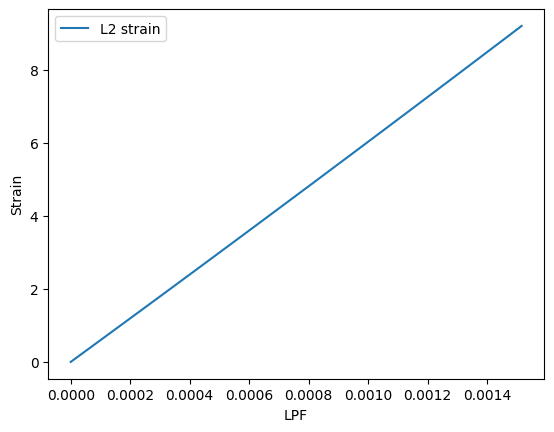

In [64]:
# strain plot

# TO DO:
M = M_perfect
elem = 2

stresses,lpfs = get_strains(M,elem)# call the right function

print(lpfs,stresses)

plt.plot(lpfs,stresses,label='L2 strain')
plt.xlabel('LPF')
plt.ylabel('Strain')
plt.legend()


In [ ]:
# rotation plot

# TO DO:
lpf,thetas= # call the right function
plt.plot(lpf,thetas,label='L2 Rotation')
plt.xlabel('LPF')
plt.ylabel('Rotation/rad')
plt.legend()

### Q2 b): Expected expansion of element L1



Use the function below to use strains to find expansions.

In [ ]:
def get_expansion(M,elem):
  """Get expansion of a element
    Args:
      M: trusspy model
      elem: the element index of interest

    Returns:
      lpfs is a list of loading proportionality factor for this elem
      expansions is a list of expansion for this elem regarding to lpfs
  """
  con=M.Elements.conns[elem-1]
  con1=con[0]
  con2=con[1]
  nc1=M.Nodes.coords[con1-1]
  nc2=M.Nodes.coords[con2-1]
  r_0=nc2-nc1
  L=np.linalg.norm(r_0)
  lpfs,strains = get_strains(M,elem)
  expansions=list(map(lambda strain:strain*L, strains))
  return lpfs,expansions


What is the expected expansion of L1 when LPF is around 1? (use the closest LPF and the corresponding values). Compare and discuss values from simulation to your results in question1.

In [ ]:
# TO DO: code to get the values (call the right functions and select values correspond to LPF = 1)


<font color=”blue”> Your Answer </font> :

Plot the expansion for L1 and L2 with respect to lpfs

In [ ]:
# expansion plot

# TO DO:
lpf,exp= # call the right function
plt.figure()
plt.plot(lpf,exp,label='L1 expansion')
plt.xlabel('LPF')
plt.ylabel('Expansion (m)')
plt.legend()

In [ ]:
# expansion plot

# TO DO:
lpf,exp= # call the right function
plt.figure()
plt.plot(lpf,exp,label='L2 expansion')
plt.xlabel('LPF')
plt.ylabel('Expansion (m)')
plt.legend()

### Q2 c): Expected loads in brace L4

What is the expected loads of these braces when LPF is around 1? (use the closest LPF and the corresponding values). Compare and discuss values from simulation to your results in question1.

In [ ]:
# TO DO: code to get the values (call the right functions and select values correspond to LPF = 1)


<font color=”blue”> Your Answer </font> :

Plot the load for L4 with respect to lpfs

In [ ]:
# L4 plots

# TO DO:
lpf,force= # call the right function
plt.plot(lpf,force,label='L4 internal force')
plt.xlabel('LPF')
plt.ylabel('internal force/N')
plt.legend()

### Q2 d): Vertical displacement of the top node

Run code below to plot the vertical displacement for L4 with respect to lpfs.
Compare and discuss values from simulation to your results in Question 1.

In [ ]:
fig, ax = M_perfect.plot_history(nodes = [6,6],X='Displacement Z')

<font color=”blue”> Your Answer </font> :